# Part 2: Model Development and Evaluation

This notebook completes the credit card fraud analysis begun in Part 1. It compares several supervised classification approaches, selects a model using cross-validation on the training data, chooses a classification threshold from out-of-fold predictions, and evaluates the final choice once on an untouched test set.

The main objective is not overall accuracy. Fraud is extremely rare, so a model that guesses "no fraud" will be highly accurate and identify zero fraudulent transactions. **Average Precision** is therefore the primary model-selection metric. Precision, recall, F1-score, the precision-recall curve, and the confusion matrix are used to interpret the final classification decisions.

## Modeling decisions

- Part 1 covers data-quality checks, exact duplicate removal, and exploratory analysis. 
- The data is split into stratified training (80%) and test (20%) sets. 
- Five-fold stratified cross-validation inside the training set is used for model comparison.
- All predictors are retained. The PCA components highlighted during EDA are not used as a whole-dataset feature-selection rule.
- The test data keeps its natural class distribution and is not used for resampling, model selection, or threshold selection.
- The threshold that maximizes out-of-fold training F1 is used as a balance between precision and recall. 

In [1]:
from pathlib import Path
from time import perf_counter
import os
import warnings

# Avoid environment-specific core-detection warnings during parallel work.
os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 1))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
CLASS_COLORS = {0: "#4C78A8", 1: "#E45756"}
LABELS = {0: "Legitimate", 1: "Fraud"}

## Load the cleaned Part 1 output

Run Part 1 first if `data/creditcard_clean.csv` does not yet exist.

In [2]:
CLEAN_DATA_PATH = Path("data/creditcard_clean.csv")

df = pd.read_csv(CLEAN_DATA_PATH)
pca_cols = [f"V{i}" for i in range(1, 29)]
expected_cols = ["Time", *pca_cols, "Amount", "Class"]

assert list(df.columns) == expected_cols, "Unexpected columns or column order."
assert df[expected_cols].apply(pd.api.types.is_numeric_dtype).all(), "All columns should be numeric."
assert df.isna().sum().sum() == 0, "The cleaned data should not contain missing values."
assert np.isfinite(df[expected_cols]).all().all(), "The cleaned data should contain only finite values."
assert df.duplicated().sum() == 0, "The cleaned data should not contain exact duplicates."
assert set(df["Class"].unique()) == {0, 1}, "Class should contain exactly 0 and 1."

data_summary = pd.Series({
    "Rows": len(df),
    "Predictors": len(expected_cols) - 1,
    "Fraud rows": int(df["Class"].sum()),
    "Fraud prevalence": df["Class"].mean(),
})
print(data_summary.to_frame("Value").to_string())

                        Value
Rows             283,726.0000
Predictors            30.0000
Fraud rows           473.0000
Fraud prevalence       0.0017


## Create the training and test sets

A stratified random split preserves approximately the same rare-class proportion in both sets. This gives the limited fraud examples more stable representation than an unstratified split. The tradeoff is that it does not simulate training on earlier transactions and predicting later ones. That limitation is revisited at the end.

In [3]:
X = df.drop(columns="Class")
y = df["Class"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    shuffle=True,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame({
    "Transactions": [len(y_train), len(y_test)],
    "Frauds": [int(y_train.sum()), int(y_test.sum())],
    "Fraud prevalence": [y_train.mean(), y_test.mean()],
}, index=["Training", "Test"])

print(split_summary.to_string())
assert y_train.sum() > 0 and y_test.sum() > 0

          Transactions  Frauds  Fraud prevalence
Training        226980     378            0.0017
Test             56746      95            0.0017


## Define the candidate models

Four approaches are compared:

1. **Dummy classifier:** establishes the no-skill reference.
2. **Weighted logistic regression:** supplies a scaled linear baseline and gives the rare class more influence during fitting.
3. **SMOTE with logistic regression:** tests whether partial synthetic oversampling helps the same basic classifier. Scaling and SMOTE are inside an imbalanced-learn pipeline, so both operations occur only within each training fold. `sampling_strategy=0.10` creates a minority count equal to 10% of the majority count rather than forcing an extreme 50/50 balance.
4. **Weighted XGBoost:** supplies a nonlinear tree-boosting model. `scale_pos_weight` is calculated from the training labels only.

SMOTE and XGBoost weighting are evaluated as separate strategies. Applying both simultaneously could overemphasize fraud and generate too many false alerts. Model comparison focuses on representative configurations to isolate the effects of class weighting, resampling, and nonlinear modeling.

In [4]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
imbalance_ratio = negative_count / positive_count

models = {
    "Dummy classifier": DummyClassifier(strategy="prior"),
    "Weighted logistic regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2_000,
            random_state=RANDOM_STATE,
        )),
    ]),
    "SMOTE logistic regression": ImbPipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(
            sampling_strategy=0.10,
            random_state=RANDOM_STATE,
        )),
        ("model", LogisticRegression(
            max_iter=2_000,
            random_state=RANDOM_STATE,
        )),
    ]),
    "Weighted XGBoost": XGBClassifier(
        objective="binary:logistic",
        eval_metric="aucpr",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=1,
        subsample=0.80,
        colsample_bytree=0.80,
        scale_pos_weight=imbalance_ratio,
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    ),
}

print(f"Training-set legitimate-to-fraud ratio: {imbalance_ratio:,.1f}:1")
print("Candidate models:")
for model_name in models:
    print(f"- {model_name}")

Training-set legitimate-to-fraud ratio: 599.5:1
Candidate models:
- Dummy classifier
- Weighted logistic regression
- SMOTE logistic regression
- Weighted XGBoost


## Compare models with stratified cross-validation

All candidates are evaluated on identical five-fold stratified cross-validation splits to ensure a consistent comparison. Out-of-fold predictions provide fraud scores for observations not used to fit their corresponding fold models, approximating unseen predictions within the training data and enabling threshold selection without consulting the test set.

Average Precision is the primary score. ROC AUC is included as a secondary ranking measure, but it can appear optimistic when the negative class is overwhelmingly large.

In [5]:
cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

fold_rows = []
oof_probabilities = {}

for model_name, estimator in models.items():
    start_time = perf_counter()
    model_oof_probability = np.zeros(len(X_train), dtype=float)

    for fold_number, (fit_positions, validation_positions) in enumerate(
        cv.split(X_train, y_train),
        start=1,
    ):
        fold_model = clone(estimator)
        X_fit = X_train.iloc[fit_positions]
        y_fit = y_train.iloc[fit_positions]
        X_validation = X_train.iloc[validation_positions]
        y_validation = y_train.iloc[validation_positions]

        fold_model.fit(X_fit, y_fit)
        fold_probability = fold_model.predict_proba(X_validation)[:, 1]
        model_oof_probability[validation_positions] = fold_probability

        fold_rows.append({
            "Model": model_name,
            "Fold": fold_number,
            "Average Precision": average_precision_score(
                y_validation, fold_probability
            ),
            "ROC AUC": roc_auc_score(y_validation, fold_probability),
        })

    oof_probabilities[model_name] = model_oof_probability
    elapsed = perf_counter() - start_time
    print(f"Completed {model_name} in {elapsed:,.1f} seconds.")

fold_results = pd.DataFrame(fold_rows)
cv_summary = (
    fold_results
    .groupby("Model")
    .agg(
        Mean_Average_Precision=("Average Precision", "mean"),
        SD_Average_Precision=("Average Precision", "std"),
        Mean_ROC_AUC=("ROC AUC", "mean"),
        SD_ROC_AUC=("ROC AUC", "std"),
    )
    .reindex(models.keys())
    .sort_values("Mean_Average_Precision", ascending=False)
)

print("\nFive-fold training results:")
print(cv_summary.to_string())

Completed Dummy classifier in 0.2 seconds.
Completed Weighted logistic regression in 2.0 seconds.
Completed SMOTE logistic regression in 3.2 seconds.
Completed Weighted XGBoost in 6.9 seconds.

Five-fold training results:
                              Mean_Average_Precision  SD_Average_Precision  Mean_ROC_AUC  SD_ROC_AUC
Model                                                                                               
Weighted XGBoost                              0.8430                0.0322        0.9831      0.0087
SMOTE logistic regression                     0.7554                0.0267        0.9789      0.0104
Weighted logistic regression                  0.7382                0.0294        0.9814      0.0090
Dummy classifier                              0.0017                0.0000        0.5000      0.0000


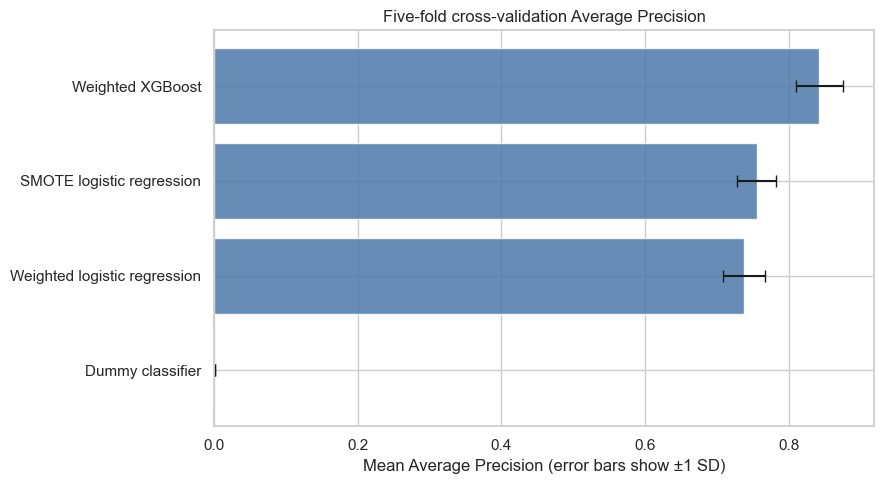

In [6]:
plot_summary = cv_summary.sort_values("Mean_Average_Precision")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    plot_summary.index,
    plot_summary["Mean_Average_Precision"],
    xerr=plot_summary["SD_Average_Precision"],
    color="#4C78A8",
    alpha=0.85,
    capsize=4,
)
ax.set(
    title="Five-fold cross-validation Average Precision",
    xlabel="Mean Average Precision (error bars show ±1 SD)",
    ylabel="",
)
plt.tight_layout()
plt.show()

## Select the model

The candidate with the highest mean cross-validation Average Precision is selected as the final model. The out-of-fold precision-recall curves show the ranking quality of all four candidates on training observations that were not used to fit their corresponding fold models. The horizontal reference line is the training fraud prevalence.

Selected model: Weighted XGBoost


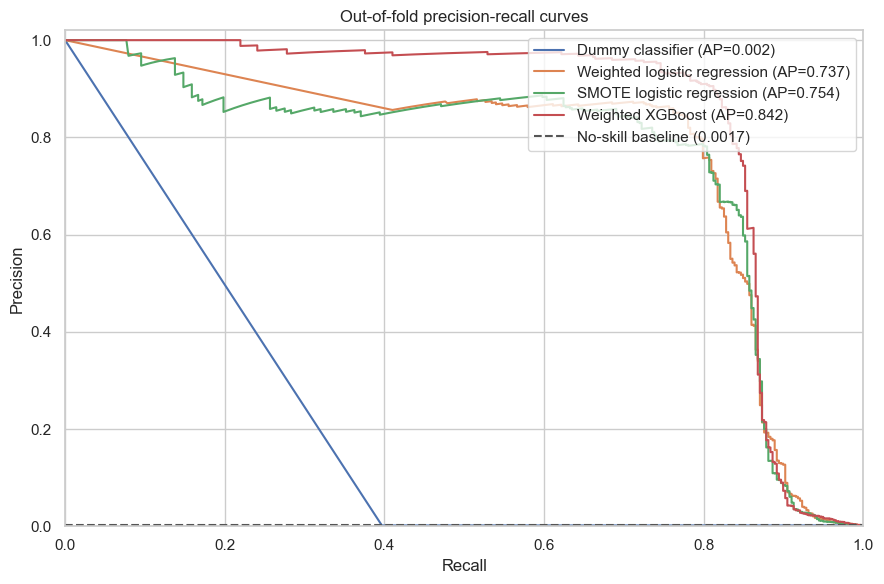

In [7]:
selected_model_name = cv_summary.index[0]
selected_oof_probability = oof_probabilities[selected_model_name]

print(f"Selected model: {selected_model_name}")

fig, ax = plt.subplots(figsize=(9, 6))
for model_name, probabilities in oof_probabilities.items():
    precision_values, recall_values, _ = precision_recall_curve(
        y_train, probabilities
    )
    model_ap = average_precision_score(y_train, probabilities)
    ax.plot(
        recall_values,
        precision_values,
        label=f"{model_name} (AP={model_ap:.3f})",
    )

ax.axhline(
    y_train.mean(),
    color="#555555",
    linestyle="--",
    label=f"No-skill baseline ({y_train.mean():.4f})",
)
ax.set(
    title="Out-of-fold precision-recall curves",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Select a classification threshold

Average Precision evaluates the probability ranking across thresholds, but operational predictions require one cutoff. The default probability cutoff of 0.50 is not assumed to be suitable for a severely imbalanced problem. Instead, the threshold that maximizes F1 on the selected model's out-of-fold training predictions is chosen.

F1 gives precision and recall equal weight, providing a transparent threshold-selection criterion when application-specific misclassification costs are unavailable.

                       Value
Selected threshold    0.9589
Out-of-fold precision 0.9056
Out-of-fold recall    0.8122
Out-of-fold F1        0.8563


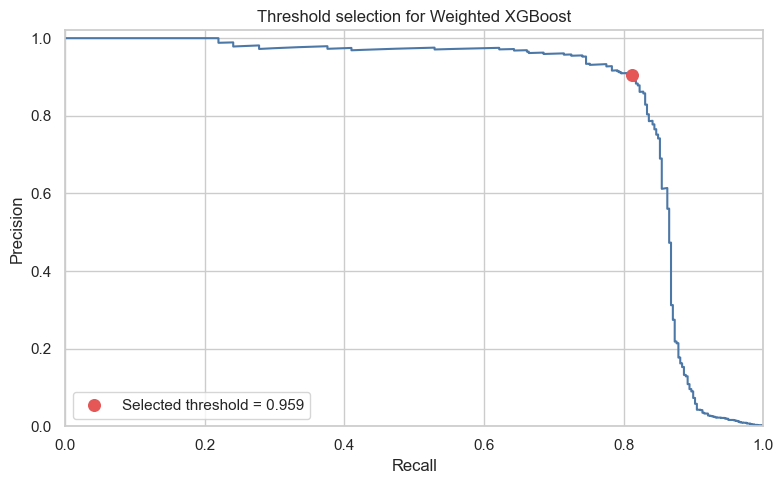

In [8]:
oof_precision, oof_recall, thresholds = precision_recall_curve(
    y_train, selected_oof_probability
)
threshold_f1 = (
    2 * oof_precision[:-1] * oof_recall[:-1]
    / (oof_precision[:-1] + oof_recall[:-1] + 1e-12)
)
best_threshold_position = int(np.nanargmax(threshold_f1))
selected_threshold = float(thresholds[best_threshold_position])

threshold_summary = pd.Series({
    "Selected threshold": selected_threshold,
    "Out-of-fold precision": oof_precision[best_threshold_position],
    "Out-of-fold recall": oof_recall[best_threshold_position],
    "Out-of-fold F1": threshold_f1[best_threshold_position],
})
print(threshold_summary.to_frame("Value").to_string())

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(oof_recall, oof_precision, color="#4C78A8")
ax.scatter(
    oof_recall[best_threshold_position],
    oof_precision[best_threshold_position],
    color="#E45756",
    s=70,
    zorder=3,
    label=f"Selected threshold = {selected_threshold:.3f}",
)
ax.set(
    title=f"Threshold selection for {selected_model_name}",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
ax.legend()
plt.tight_layout()
plt.show()

## Fit the selected model on the complete training set

After model and threshold selection, the selected estimator is refitted on the complete training set before final test evaluation.

In [9]:
final_model = clone(models[selected_model_name])
final_model.fit(X_train, y_train)
print(f"Fitted {selected_model_name} on {len(X_train):,} training transactions.")

Fitted Weighted XGBoost on 226,980 training transactions.


## Final test evaluation

The untouched test set is evaluated once using the frozen model and threshold. Average Precision remains the primary ranking metric. Precision, recall, F1, and the confusion matrix describe behavior at the selected operating threshold. Accuracy is included only to illustrate how strongly the majority class dominates the data.

In [10]:
test_probability = final_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= selected_threshold).astype(int)

test_confusion_matrix = confusion_matrix(
    y_test, test_prediction, labels=[0, 1]
)
true_negative, false_positive, false_negative, true_positive = (
    test_confusion_matrix.ravel()
)

test_metrics = pd.Series({
    "Average Precision": average_precision_score(y_test, test_probability),
    "ROC AUC": roc_auc_score(y_test, test_probability),
    "Precision": precision_score(y_test, test_prediction, zero_division=0),
    "Recall": recall_score(y_test, test_prediction, zero_division=0),
    "F1": f1_score(y_test, test_prediction, zero_division=0),
    "Accuracy (context only)": accuracy_score(y_test, test_prediction),
    "True negatives": true_negative,
    "False positives": false_positive,
    "False negatives": false_negative,
    "True positives": true_positive,
})

print(f"Final model: {selected_model_name}")
print(f"Classification threshold: {selected_threshold:.6f}\n")
print(test_metrics.to_frame("Test result").to_string())

Final model: Weighted XGBoost
Classification threshold: 0.958945

                         Test result
Average Precision             0.8118
ROC AUC                       0.9707
Precision                     0.9103
Recall                        0.7474
F1                            0.8208
Accuracy (context only)       0.9995
True negatives           56,644.0000
False positives               7.0000
False negatives              24.0000
True positives               71.0000


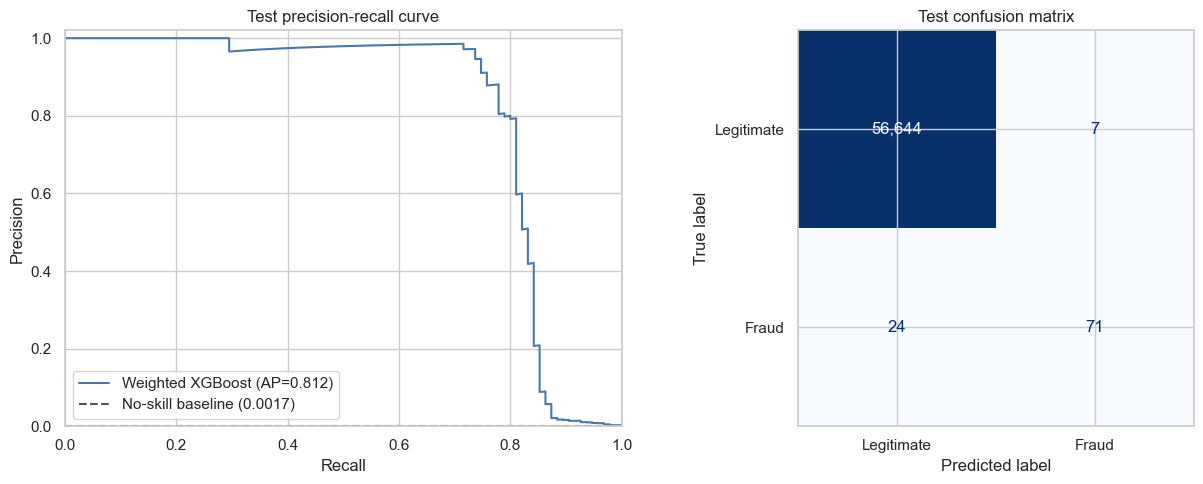

In [11]:
test_precision, test_recall, _ = precision_recall_curve(
    y_test, test_probability
)
test_ap = average_precision_score(y_test, test_probability)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(
    test_recall,
    test_precision,
    color="#4C78A8",
    label=f"{selected_model_name} (AP={test_ap:.3f})",
)
axes[0].axhline(
    y_test.mean(),
    color="#555555",
    linestyle="--",
    label=f"No-skill baseline ({y_test.mean():.4f})",
)
axes[0].set(
    title="Test precision-recall curve",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
axes[0].legend()

ConfusionMatrixDisplay(
    confusion_matrix=test_confusion_matrix,
    display_labels=[LABELS[0], LABELS[1]],
).plot(ax=axes[1], cmap="Blues", colorbar=False, values_format=",d")
axes[1].set_title("Test confusion matrix")

plt.tight_layout()
plt.show()

## Error analysis

False positives are legitimate transactions incorrectly flagged for review. False negatives are fraudulent transactions the model missed. Error analysis compares transaction amount, elapsed time, and predicted risk across all four confusion matrix outcomes. It is descriptive only: the findings are not used to revise the model after viewing the test data.

In [12]:
test_results = X_test[["Time", "Amount"]].copy()
test_results["Actual"] = y_test.to_numpy()
test_results["Predicted"] = test_prediction
test_results["Fraud probability"] = test_probability
test_results["Elapsed hours"] = test_results["Time"] / 3_600

conditions = [
    (test_results["Actual"] == 0) & (test_results["Predicted"] == 0),
    (test_results["Actual"] == 0) & (test_results["Predicted"] == 1),
    (test_results["Actual"] == 1) & (test_results["Predicted"] == 0),
    (test_results["Actual"] == 1) & (test_results["Predicted"] == 1),
]
outcomes = ["True negative", "False positive", "False negative", "True positive"]
test_results["Outcome"] = np.select(
    conditions, outcomes, default="Unclassified"
)
test_results["Outcome"] = pd.Categorical(
    test_results["Outcome"], categories=outcomes, ordered=True
)

error_summary = (
    test_results
    .groupby("Outcome", observed=True)
    .agg(
        Transactions=("Actual", "size"),
        Median_amount=("Amount", "median"),
        Mean_amount=("Amount", "mean"),
        Median_elapsed_hour=("Elapsed hours", "median"),
        Median_fraud_probability=("Fraud probability", "median"),
    )
)
print(error_summary.to_string())

                Transactions  Median_amount  Mean_amount  Median_elapsed_hour  Median_fraud_probability
Outcome                                                                                                
True negative          56644        21.6000      88.7087              23.4668                    0.0004
False positive             7        10.6100      44.4971              11.5122                    0.9778
False negative            24         2.9900     168.8137              18.3550                    0.0151
True positive             71        33.5900     150.9124              21.1050                    0.9997


## Permutation feature importance

Permutation importance measures how much Average Precision on the test set decreases when one predictor is randomly shuffled.

Larger decreases indicate that the fitted model relied more heavily on that variable. This analysis is performed only after final evaluation and is not used for feature selection or model tuning.

The PCA components remain anonymized, so their importance cannot be translated into unsupported business explanations.

Feature  Importance mean  Importance SD
     V4           0.0755         0.0168
    V14           0.0739         0.0056
    V11           0.0408         0.0089
    V12           0.0358         0.0075
    V26           0.0122         0.0047
     V3           0.0104         0.0107
    V28           0.0093         0.0015
     V7           0.0070         0.0043
    V10           0.0064         0.0017
 Amount           0.0059         0.0028


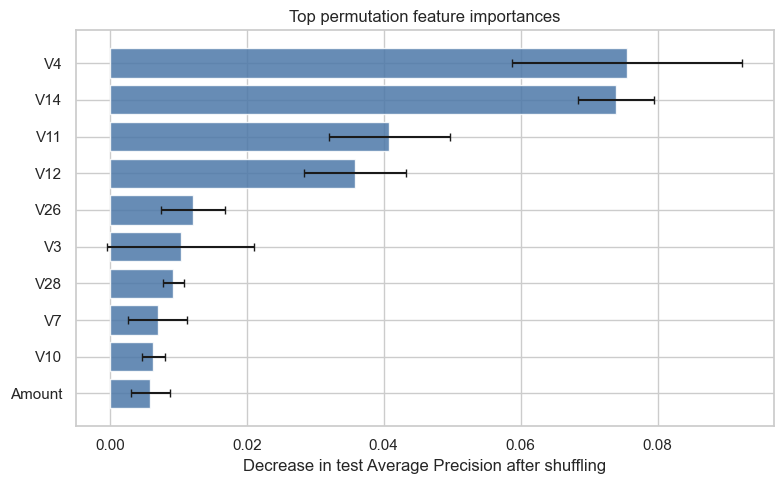

In [13]:
importance_result = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importance mean": importance_result.importances_mean,
        "Importance SD": importance_result.importances_std,
    })
    .sort_values("Importance mean", ascending=False)
)
top_importance = importance_df.head(10).sort_values("Importance mean")

print(importance_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(
    top_importance["Feature"],
    top_importance["Importance mean"],
    xerr=top_importance["Importance SD"],
    color="#4C78A8",
    alpha=0.85,
    capsize=3,
)
ax.set(
    title="Top permutation feature importances",
    xlabel="Decrease in test Average Precision after shuffling",
    ylabel="",
)
plt.tight_layout()
plt.show()

## Limitations

- The data covers only about two days of transactions from September 2013, so it cannot represent long-term changes in fraud behavior.
- A stratified random split preserves approximately the same fraud prevalence in both sets, providing more stable representation of the small number of fraud cases than an unstratified split. The tradeoff is that it does not simulate training on earlier transactions and predicting later ones.
- Part 1 explored class differences using the full cleaned dataset. To limit further test influence, this notebook retained every predictor and did not use the EDA ranking as a feature-selection rule.
- The threshold maximizes F1 and therefore assigns equal importance to precision and recall. Operational threshold selection should incorporate institution-specific misclassification costs and investigation capacity.
- Class weighting can affect probability calibration. The selected model's outputs are useful ranking scores, but they should not be interpreted as calibrated fraud probabilities without a separate calibration assessment.
- SMOTE generates synthetic examples rather than additional observed fraud cases. Its cross-validation performance must be compared with weighting rather than assumed to be better.
- `V1` through `V28` are anonymized PCA components. The original feature definitions and fitted PCA transformation are unavailable, preventing end-to-end scoring of raw banking transactions.
- The results demonstrate a robust supervised modeling workflow on this dataset, while additional validation and operational testing would be required before deployment.

## Conclusion

Weighted XGBoost produced the strongest cross-validation performance and maintained strong discrimination on the untouched test set, achieving 0.8118 Average Precision with 0.9103 precision, 0.7474 recall, and 0.8208 F1 at the selected threshold.

In [14]:
print(f"Selected model: {selected_model_name}")
print(f"Five-fold mean validation Average Precision: "
      f"{cv_summary.loc[selected_model_name, 'Mean_Average_Precision']:.4f}")
print(f"Selected classification threshold: {selected_threshold:.6f}")
print(f"Test Average Precision: {test_metrics['Average Precision']:.4f}")
print(f"Test precision: {test_metrics['Precision']:.4f}")
print(f"Test recall: {test_metrics['Recall']:.4f}")
print(f"Test F1: {test_metrics['F1']:.4f}")
print(f"False positives: {int(test_metrics['False positives']):,}")
print(f"False negatives: {int(test_metrics['False negatives']):,}")

Selected model: Weighted XGBoost
Five-fold mean validation Average Precision: 0.8430
Selected classification threshold: 0.958945
Test Average Precision: 0.8118
Test precision: 0.9103
Test recall: 0.7474
Test F1: 0.8208
False positives: 7
False negatives: 24
